In [34]:
using Plots                          # Plotting
using CSV, DataFrames, JLD2          # Data handling
using LinearAlgebra, StatsBase       # Linear algebra, statistics
using Random, Statistics             # Random number generation, basic statistics
using LaTeXStrings                   # LaTeX support for plots
using Revise                          # Live code reloading

using StaticArrays, LazySets          # Efficient arrays, set operations
using Interpolations, LinearInterpolations  # Interpolation utilities
using SpatiotemporalGPs               # Gaussian processes
using DifferentialEquations, ForwardDiff # Differential equations, automatic differentiation
using Distributions, StatsPlots, SpecialFunctions, Glob # Wind Transformatoins


In [35]:
# Import modules
include("../src/jordan_lake_domain.jl")
# include("../src/stgpkf.jl")
include("../src/kf.jl")
include("../src/ngpkf.jl")
include("../src/SyntheticData.jl")
include("../src/ergodic.jl")
include("../src/variograms.jl")
include("../src/SOC_Controller.jl")
include("../src/simulator_spatial.jl")
include("../src/simulator_ST.jl")
include("../src/Convex_bound_avoidance.jl")
include("../src/transects.jl")

┌ Warning: Replacing docs for `Main.Variograms.hp_fit :: Tuple{Any}` in module `Main.Variograms`
└ @ Base.Docs docs/Docs.jl:243


Main.Transects

In [36]:
# Plot Settings
plot_font = "Computer Modern"
default(
    fontfamily=plot_font,
    linewidth=2,
    guidefontsize=14,
    tickfontsize=14,
    legendfontsize=10,
    titlefontsize=18
)

# Mission domain
polygon_vertices = hcat(JordanLakeDomain.convex_polygon.vertices, JordanLakeDomain.convex_polygon.vertices[:, 1])  # Close the polygon
x0s = [@SVector[0.75, 0.75] for i=1:1]

# Define simulation time-scale/steps
Δt = 2.5 # seconds
dt_min = Δt/(60) # convert ΔT from seconds to minutes
dt_hrs = Δt/(60*60) # convert ΔT from seconds to hours
T_begin = 9.0; # hours
T_end = 12.0; # hours 
ts_hrs = T_begin:dt_hrs:T_end # hours
ts_min = T_begin*60:dt_min:T_end*60


# setup the spatial and temporal kernels
σt = 1.0   # m/s
σs = 1.0 # m/s
σm = 0.5   # m/s
lt = 0.75*60.0  # minutes
ls = 1.0   # km

kt = Matern(1/2, σt, lt) # temporal kernel
ks = Matern(1/2, σs, ls) # spatial kernel

# Create the spatial domain
dx = 0.05 # spatial step size in km
xs = 0:dx:1.6
ys = 0:dx:1.9
grid_pts = vec([@SVector[x, y] for x in xs, y in ys]);


In [37]:
file_path = "20250415_transect_lt45_ls10.jld2"
f = jldopen(file_path, "r")
transect_res_ergo_hp = f["res_ergo_hp"]
transect_synthetic_data = f["synthetic_data"]
transect_soc_target = f["soc_target"]
transect_ts_hrs = f["ts_hrs"]
transect_w_rated_val = f["w_rated_val"]
close(f)

In [38]:
# Clarity Functions
S(p,x) = (1/Δt) * (ks(p,x)^2 / (ks(p,p) * (ks(x,x) + σm^2) - ks(p,x)^2))
D(p,q) = 2 * lt * ((σt^2 + 1)*(q^2) - q)

D (generic function with 1 method)

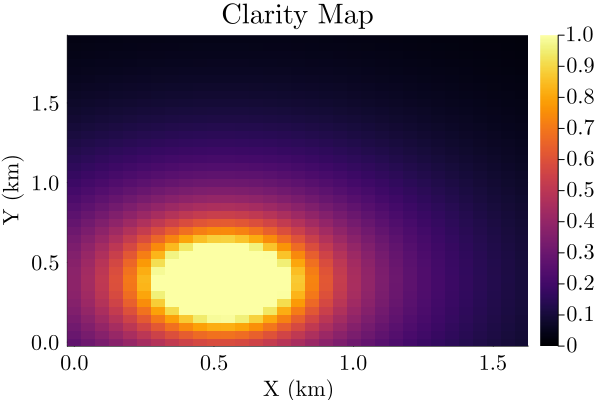

In [39]:
# Initialize clarity map
clarity_map = zeros(length(grid_pts))

for i in 1:length(grid_pts)
    # Get the current grid point
    grid_point = grid_pts[i]

    # Get the corresponding transect point
    transect_point = transect_res_ergo_hp.xs[1502][1]
    clarity_value = clarity_map[i]

    # Calculate the clarity value using the ergodic function
    clarity_value += (S(grid_point, transect_point) * (1.0 - clarity_value)^2 - D(grid_point, clarity_value)) * Δt

    # Store the clarity value in the map
    # clarity_map[i] = min(max(clarity_value, 0.0), 1.0)
    clarity_map[i] = clarity_value;
end

# Reshape clarity map to match the spatial domain
clarity_map_reshaped = reshape(clarity_map, length(xs), length(ys))

# Plot the clarity map
heatmap(xs, ys, clarity_map_reshaped', clims=(0,1), xlabel="X (km)", ylabel="Y (km)", title="Clarity Map")

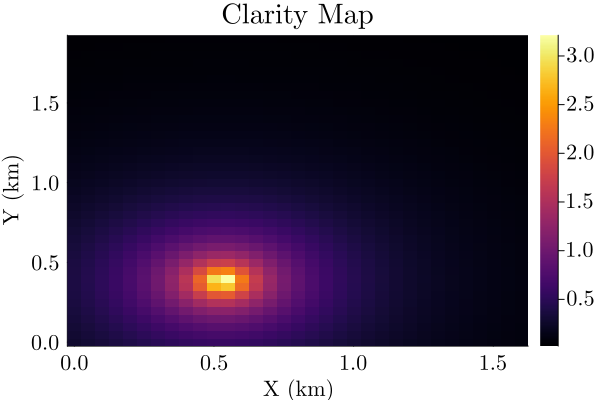

In [40]:
heatmap(xs, ys, clarity_map_reshaped', xlabel="X (km)", ylabel="Y (km)", title="Clarity Map")

In [ ]:
function rk4_step(f, y, t, h)
    k1 = f(t, y)
    k2 = f(t + 0.5h, y + 0.5h * k1)
    k3 = f(t + 0.5h, y + 0.5h * k2)
    k4 = f(t + h, y + h * k3)
    return y + (h / 6.0) * (k1 + 2k2 + 2k3 + k4)
end

function clarity_dynamics(t, clarity_value, grid_point)
    transect_point = transect_res_ergo_hp.xs[Int64(t)][1]
    return S(grid_point, transect_point) * (1 - clarity_value)^2 - D(grid_point, clarity_value)
end

clarity_reconstruction = zeros(length(grid_pts), length(transect_res_ergo_hp.xs))
for idx in 1:length(transect_res_ergo_hp.xs)
    if idx == 1
        clarity_map = zeros(length(grid_pts))
    else
        clarity_map = clarity_reconstruction[:, idx-1]
    end

    for i in 1:length(grid_pts)
        # Get the current grid point
        grid_point = grid_pts[i]
    
        # Get the current clarity value
        clarity_value = clarity_map[i]
    
        # Calculate the clarity value using the RK4 method
        clarity_value = rk4_step((t, y) -> clarity_dynamics(t, y, grid_point), clarity_value, idx, Δt)
    
        # Store the clarity value in the reconstruction
        clarity_reconstruction[i, idx] = clarity_value
    end
end

clarity_reconstruction_reshaped = reshape(clarity_reconstruction, length(xs), length(ys), length(transect_res_ergo_hp.xs))


InexactError: InexactError: Int64(2.25)

┌ Info: Saved animation to /tmp/jl_Z4H6LCjQzo.gif
└ @ Plots /home/kmgovind/.julia/packages/Plots/Ec1L1/src/animation.jl:156


Plots.AnimatedGif("/tmp/jl_Z4H6LCjQzo.gif")
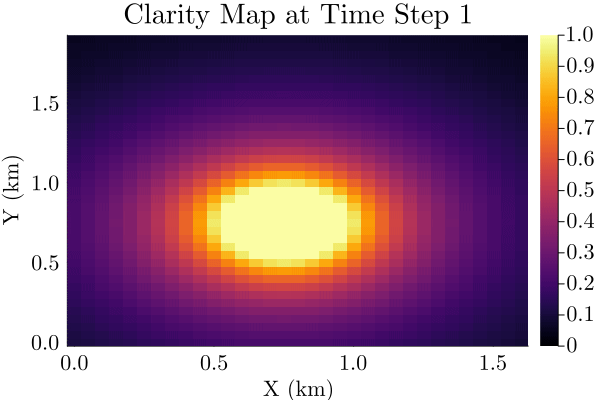

In [42]:
@gif for i in 1:50:length(transect_res_ergo_hp.xs)
    # Plot the clarity map
    heatmap(xs, ys, clarity_reconstruction_reshaped[:, :, i]', clims=(0,1), xlabel="X (km)", ylabel="Y (km)", title="Clarity Map at Time Step $i");
end

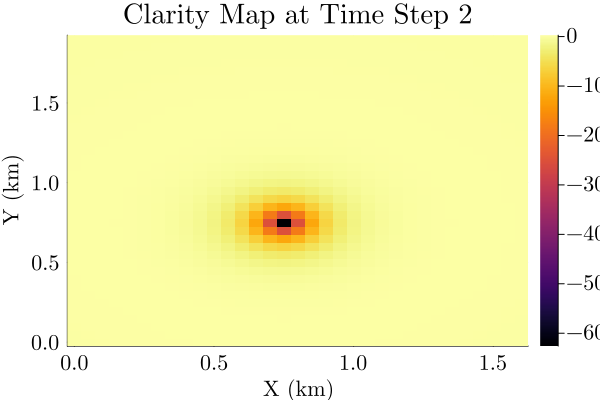

In [43]:
i=2
heatmap(xs, ys, clarity_reconstruction_reshaped[:, :, i]', xlabel="X (km)", ylabel="Y (km)", title="Clarity Map at Time Step $i")

┌ Info: Saved animation to /tmp/jl_t6l2fmTkvo.gif
└ @ Plots /home/kmgovind/.julia/packages/Plots/Ec1L1/src/animation.jl:156


Plots.AnimatedGif("/tmp/jl_t6l2fmTkvo.gif")
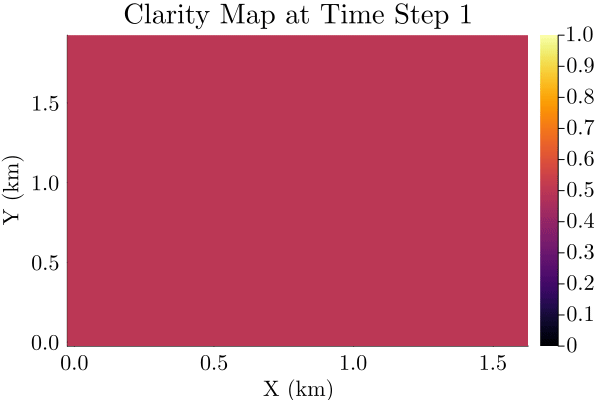

In [44]:
@gif for i in 1:50:length(transect_res_ergo_hp.ergo_q_maps)
    # Plot the clarity map
    heatmap(xs, ys, transect_res_ergo_hp.ergo_q_maps[i]', clims=(0,1), xlabel="X (km)", ylabel="Y (km)", title="Clarity Map at Time Step $i");
end